In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = "data/raw_sales_data_50_messy.csv"

df = pd.read_csv(file_path)

In [4]:
df

,Order_ID,Order_Date,Customer_Name,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Payment_Mode,Order_Status,Customer_Email,Discount,Rating
0,ORD1001,2025-03-02,Ananya Das,female,Coimbatore,Watch,Fashion,4.0,7000,28000.0,upi,DELIVERED,ananya.das@gmail.com,0.0,3.0
1,ORD1002,2025-01-24,Ananya Das,M,chennai,Headphones,Electronics,5.0,3500,14875.0,credit card,delivered,ananya.das@gmail.com,15.0,4.0
2,ORD1003,2025-02-02,Karthik Iyer,Female,Bangalore,Shoes,Fashion,2.0,4500,7650.0,Cash,pending,karthik.iyer@gmail.com,15.0,4.0
3,ORD1004,2025-04-02,NaN,Female,Madurai,Laptop,Electronics,1.0,55000,49500.0,cash,Cancelled,meena.rao@gmail.com,10.0,3.0
4,ORD1005,2025-01-03,Suresh Verma,female,Hyderabad,Office Chair,Furniture,4.0,12000,40800.0,cash,pending,suresh.verma@gmail.com,15.0,1.0
5,ORD1006,2025-03-01,Suresh Verma,F,CHENNAI,Watch,Fashion,2.0,7000,11900.0,upi,Delivered,suresh.verma@gmail.com,15.0,2.0
6,ORD1007,2025-02-13,Rahul Kumar,female,Madurai,Backpack,Accessories,2.0,2200,3740.0,cash,DELIVERED,vijay.nair@gmail.com,15.0,1.0
7,ORD1008,2025-01-02,Divya Singh,m,Pune,Office Chair,Furniture,2.0,12000,20400.0,Cash,delivered,divya.singh@gmail.com,15.0,4.0
8,ORD1009,2025-03-31,Priya Sharma,Female,NaN,Shoes,Fashion,5.0,4500,20250.0,upi,Cancelled,priya.sharma@gmail.com,10.0,4.0
9,ORD1010,2025-03-26,Ananya Das,female,Bangalore,Shoes,Fashion,4.0,4500,18000.0,cash,pending,ananya.das@gmail.com,0.0,2.0


In [3]:
df.head()

,Order_ID,Order_Date,Customer_Name,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Payment_Mode,Order_Status,Customer_Email,Discount,Rating
0,ORD1001,2025-03-02,Ananya Das,female,Coimbatore,Watch,Fashion,4.0,7000,28000.0,upi,DELIVERED,ananya.das@gmail.com,0.0,3.0
1,ORD1002,2025-01-24,Ananya Das,M,chennai,Headphones,Electronics,5.0,3500,14875.0,credit card,delivered,ananya.das@gmail.com,15.0,4.0
2,ORD1003,2025-02-02,Karthik Iyer,Female,Bangalore,Shoes,Fashion,2.0,4500,7650.0,Cash,pending,karthik.iyer@gmail.com,15.0,4.0
3,ORD1004,2025-04-02,NaN,Female,Madurai,Laptop,Electronics,1.0,55000,49500.0,cash,Cancelled,meena.rao@gmail.com,10.0,3.0
4,ORD1005,2025-01-03,Suresh Verma,female,Hyderabad,Office Chair,Furniture,4.0,12000,40800.0,cash,pending,suresh.verma@gmail.com,15.0,1.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        50 non-null     str    
 1   Order_Date      50 non-null     str    
 2   Customer_Name   49 non-null     str    
 3   Gender          50 non-null     str    
 4   City            49 non-null     str    
 5   Product         50 non-null     str    
 6   Category        50 non-null     str    
 7   Quantity        49 non-null     float64
 8   Unit_Price      50 non-null     int64  
 9   Total_Sales     50 non-null     float64
 10  Payment_Mode    49 non-null     str    
 11  Order_Status    50 non-null     str    
 12  Customer_Email  49 non-null     str    
 13  Discount        49 non-null     float64
 14  Rating          49 non-null     float64
dtypes: float64(4), int64(1), str(10)
memory usage: 6.0 KB


In [6]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_Name     1
Gender            0
City              1
Product           0
Category          0
Quantity          1
Unit_Price        0
Total_Sales       0
Payment_Mode      1
Order_Status      0
Customer_Email    1
Discount          1
Rating            1
dtype: int64

In [9]:
df["Customer_Name"]=df["Customer_Name"].fillna(df["Customer_Name"].mode()[0])
df["City"]=df["City"].fillna(df["City"].mode()[0])
df["Quantity"]=df["Quantity"].fillna(df["Quantity"].mean())
df["Payment_Mode"]=df["Payment_Mode"].fillna(df["Payment_Mode"].mode()[0])
df["Customer_Email"]=df["Customer_Email"].fillna(df["Customer_Email"].mode()[0])
df["Discount"]=df["Discount"].fillna(df["Discount"].mean())
df["Rating"]=df["Rating"].fillna(df["Rating"].mean())


In [10]:
df=df.drop_duplicates()

In [12]:
print("Total Sales :", df["Total_Sales"].sum())
print("Average Sales :", df["Total_Sales"].mean())
print("Maximum Sales :", df["Total_Sales"].max())
print("Minimum Sales :", df["Total_Sales"].min())

Total Sales : 2277724.0
Average Sales : 46484.163265306124
Maximum Sales : 275000.0
Minimum Sales : 500.0


In [13]:
sales = df.groupby("Category")["Total_Sales"].sum()
sales

Category
Accessories      25850.0
Electronics    1704499.0
Fashion         187975.0
Furniture       359400.0
Name: Total_Sales, dtype: float64

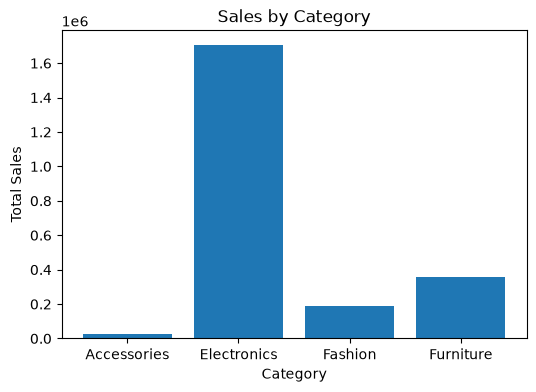

In [14]:
plt.figure(figsize=(6,4))
plt.bar(sales.index, sales.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

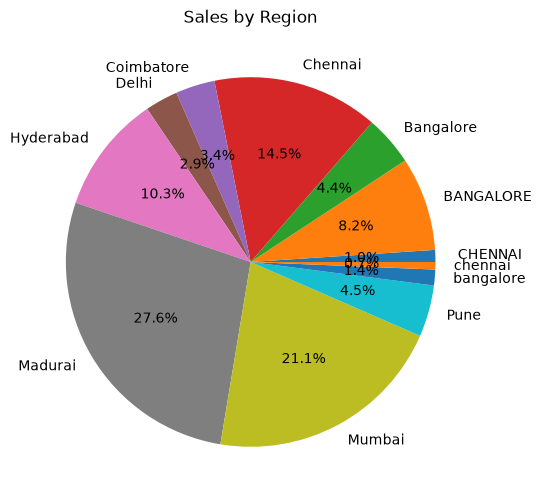

In [16]:
region = df.groupby("City")["Total_Sales"].sum()

plt.figure(figsize=(6,6))
plt.pie(region.values,
        labels=region.index,
        autopct="%1.1f%%")

plt.title("Sales by Region")
plt.show()

In [17]:
df.to_csv("raw_sales_data_50_messy.csv", index=False)